In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample_nom', '122',
        '--data_nsample_exc', '528',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.8',

        '--lookback_nsample', '64',
        '--forecast_nsample', '32',

        '--batch_size', '64',
        '--learning_rate', '0.002',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '32',
        '--seg_nsample_trans', '16',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample_nom, args.data_nsample_exc,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

>>> regime separator is computed as 0.5600000023841858


In [7]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.000634, valid=0.220432, test=0.262086
	validation loss decreased (inf -> 0.220432), saving model ...
	epoch 2 losses: train=0.230693, valid=0.019865, test=0.021158
	validation loss decreased (0.220432 -> 0.019865), saving model ...
	epoch 3 losses: train=0.018982, valid=0.041315, test=0.036903
	early stopping counter: 1 out of 100
	epoch 4 losses: train=0.044907, valid=0.075141, test=0.106430
	early stopping counter: 2 out of 100
	epoch 5 losses: train=0.081982, valid=0.079942, test=0.130734
	early stopping counter: 3 out of 100
	epoch 6 losses: train=0.081809, valid=0.077523, test=0.110255
	early stopping counter: 4 out of 100
	epoch 7 losses: train=0.066310, valid=0.063783, test=0.070682
	early stopping counter: 5 out of 100
	epoch 8 losses: train=0.043849, valid=0.045921, test=0.033478
	early stopping counter: 6 out of 100
	epoch 9 losses: train=0.025711, valid=0.031314, test=0.011655
	early stopping counter: 7 out of 100
	epoch

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

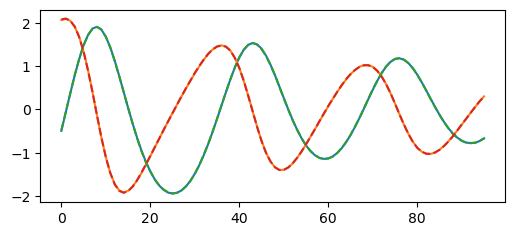

NameError: name 'tata' is not defined

In [9]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,2.5))
        plt.plot(true[jdata, :, :2])
        plt.plot(mean_nom[0, :, :2], linestyle='dashed')

        plt.show()

        break

print(tata.shape)

In [19]:
model.train()
#training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.145596, valid=0.119009, test=0.065447
	validation loss decreased (inf -> 0.119009), saving model ...
	epoch 2 losses: train=0.151212, valid=0.118026, test=0.068257
	validation loss decreased (0.119009 -> 0.118026), saving model ...
	epoch 3 losses: train=0.133344, valid=0.102292, test=0.057599
	validation loss decreased (0.118026 -> 0.102292), saving model ...
	epoch 4 losses: train=0.098228, valid=0.111905, test=0.054001
	early stopping counter: 1 out of 100
	epoch 5 losses: train=0.095878, valid=0.117657, test=0.052314
	early stopping counter: 2 out of 100
	epoch 6 losses: train=0.093648, valid=0.112883, test=0.049988
	early stopping counter: 3 out of 100
	epoch 7 losses: train=0.088709, valid=0.108903, test=0.046340
	early stopping counter: 4 out of 100
	epoch 8 losses: train=0.080936, valid=0.110276, test=0.044371
	early stopping counter: 5 out of 100
	epoch 9 losses: train=0.075110, valid=0.114387, test=0.047537
	early 

In [20]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

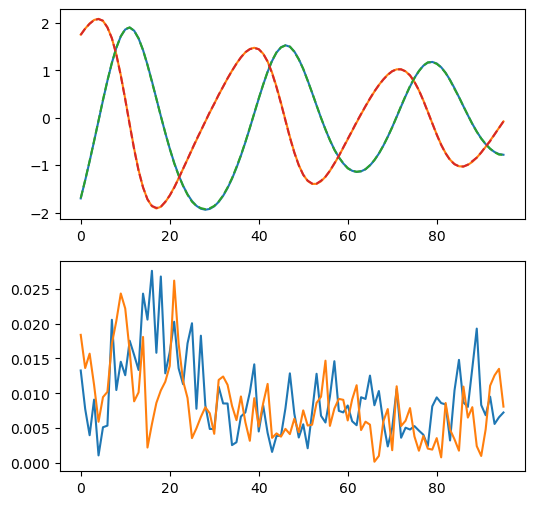

In [22]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_nom[0, :, :2])

        plt.show()

        break

#print(tata.shape)

In [23]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=1.021090, valid=0.993876, test=0.892051
	validation loss decreased (inf -> 0.993876), saving model ...
	epoch 2 losses: train=0.964113, valid=0.954005, test=0.844528
	validation loss decreased (0.993876 -> 0.954005), saving model ...
	epoch 3 losses: train=0.925207, valid=0.920735, test=0.794534
	validation loss decreased (0.954005 -> 0.920735), saving model ...
	epoch 4 losses: train=0.880798, valid=0.874443, test=0.735866
	validation loss decreased (0.920735 -> 0.874443), saving model ...
	epoch 5 losses: train=0.817136, valid=0.811905, test=0.679442
	validation loss decreased (0.874443 -> 0.811905), saving model ...
	epoch 6 losses: train=0.765322, valid=0.763509, test=0.627344
	validation loss decreased (0.811905 -> 0.763509), saving model ...
	epoch 7 losses: train=0.715796, valid=0.732948, test=0.608279
	validation loss decreased (0.763509 -> 0.732948), saving model ...
	epoch 8 losses: train=0.678919, valid=0.693928, test=0.

In [24]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

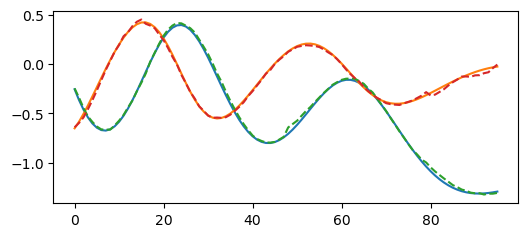

In [33]:
jdata = 7

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        stat = model_o.mean_exc

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [34]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.223743, valid=0.150233, test=0.043689
	validation loss decreased (inf -> 0.150233), saving model ...
	epoch 2 losses: train=0.200241, valid=0.144604, test=0.039304
	validation loss decreased (0.150233 -> 0.144604), saving model ...
	epoch 3 losses: train=0.193512, valid=0.141731, test=0.037735
	validation loss decreased (0.144604 -> 0.141731), saving model ...
	epoch 4 losses: train=0.191952, valid=0.139482, test=0.036407
	validation loss decreased (0.141731 -> 0.139482), saving model ...
	epoch 5 losses: train=0.187478, valid=0.137552, test=0.035176
	validation loss decreased (0.139482 -> 0.137552), saving model ...
	epoch 6 losses: train=0.185374, valid=0.136025, test=0.034504
	validation loss decreased (0.137552 -> 0.136025), saving model ...
	epoch 7 losses: train=0.184139, valid=0.134979, test=0.034496
	validation loss decreased (0.136025 -> 0.134979), saving model ...
	epoch 8 losses: train=0.181254, valid=0.134303, 

In [35]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

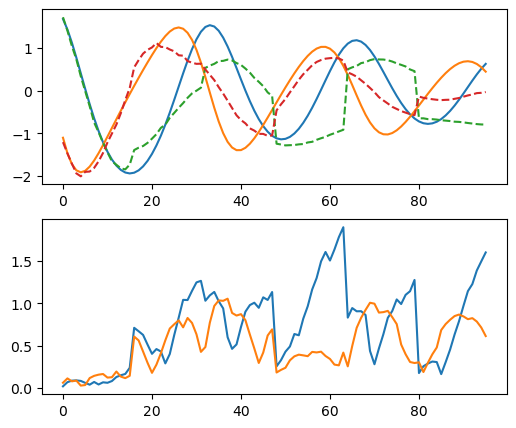

In [37]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        exc = model_o.mean_exc
        exc_u = model_o.zeta_exc

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

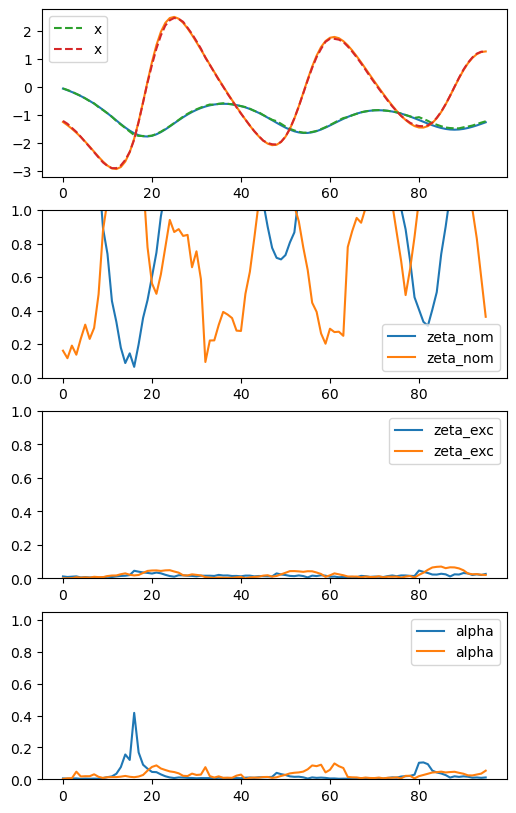

In [38]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break